# Лабораторна робота № 2 — Класифікація та аналіз помилок моделі

**Варіант 5.** Набір даних: **Wine Dataset**, цільова ознака `class` (тип вина).

**Увага:** у цій роботі варіанти **інші**, ніж у ЛР № 1. Тут варіант 5 — це Wine,
а не Breast Cancer.

**Мета роботи.** Побудувати й оцінити модель бінарної класифікації,
проаналізувати матрицю помилок, дослідити помилки типів False Positive і False
Negative, використати метрики Accuracy, Precision, Recall, F1 та ROC-AUC,
дослідити вплив порога класифікації та обґрунтувати придатність моделі для
конкретної прикладної задачі.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_wine
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve,
                             precision_recall_fscore_support, make_scorer)

RANDOM_STATE = 42
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

# Одна схема CV для baseline і всіх моделей. Stratified — бо класи незбалансовані.
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(CV)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 1. Постановка задачі та початковий аналіз даних

### Що це за дані

**Wine Dataset** — результати хімічного аналізу вин, вирощених в **одному й тому
самому регіоні Італії**, але з **трьох різних сортів винограду** (cultivars).
Для кожного зразка виміряно 13 хімічних показників: вміст алкоголю, яблучної
кислоти, магнію, флавоноїдів, інтенсивність кольору, вміст проліну тощо.

**Обʼєкт спостереження** — один зразок вина.
**Вхідні ознаки** — 13 числових результатів хімічного аналізу.
**Цільова змінна** — сорт винограду, з якого зроблено вино.

### Прикладна задача

Набір описує задачу **верифікації сорту**: за хімічним аналізом підтвердити або
спростувати, що вино виготовлене із заявленого сорту винограду. Практичний сенс —
контроль автентичності: підміна сорту дешевшим є поширеним видом фальсифікації,
а хімічний аналіз дешевший за дегустаційну експертизу.

### Перетворення на бінарну задачу

У наборі **три класи**, а робота вимагає **бінарної** класифікації. Тому задачу
зводжу до схеми «один проти решти»: обираю один сорт, який перевіряємо, і
запитуємо «це він чи не він».

Це рішення треба обґрунтувати, а не взяти навмання — обґрунтування нижче, після
того як подивлюся на дані.

In [2]:
data = load_wine(as_frame=True)
df = data.frame.copy()
FEATURES = list(data.feature_names)

print("розмір набору:", df.shape)
print("\nтипи ознак:")
print(df[FEATURES].dtypes.value_counts().to_string())
print("\nпропущені значення:", int(df.isnull().sum().sum()))
print("повні дублікати:", int(df.duplicated().sum()))
print("\nрозподіл за трьома сортами:")
print(df["target"].value_counts().sort_index().to_string())
df.head()

розмір набору: (178, 14)

типи ознак:
float64    13

пропущені значення: 0
повні дублікати: 0

розподіл за трьома сортами:
target
0    59
1    71
2    48


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Який сорт найменш відокремлений? Рахуємо відстані між центрами класів
# у просторі стандартизованих ознак.
Z = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
centers = Z.groupby(df["target"]).mean()
dist = pd.DataFrame(
    [[np.linalg.norm(centers.loc[i] - centers.loc[j]) for j in centers.index] for i in centers.index],
    index=[f"сорт {i}" for i in centers.index], columns=[f"сорт {j}" for j in centers.index])

print("Відстані між центрами класів (стандартизовані ознаки):")
print(dist.round(2).to_string())
print("\nСередня відстань кожного сорту до двох інших:")
print((dist.sum(axis=1) / 2).round(2).to_string())

Відстані між центрами класів (стандартизовані ознаки):
        сорт 0  сорт 1  сорт 2
сорт 0    0.00    3.56    5.06
сорт 1    3.56    0.00    3.98
сорт 2    5.06    3.98    0.00

Середня відстань кожного сорту до двох інших:
сорт 0    4.31
сорт 1    3.77
сорт 2    4.52


### Вибір позитивного класу

Відстані між центрами показують, що **сорт 1 лежить між двома іншими**: до сорту 0
він ближчий, ніж сорт 0 до сорту 2, і до сорту 2 — так само. Тобто сорт 1 —
найменш хімічно відокремлений.

**Позитивним класом ($y = 1$) обираю сорт 1**, негативним ($y = 0$) — решту.
Обґрунтування:

1. **Прикладне.** Саме найменш відокремлений сорт найважче відрізнити за
   аналізом, тому задача його верифікації має реальний зміст. Перевіряти сорт,
   який і так очевидно відрізняється, практично не потрібно.
2. **Він найчисленніший** — 71 зразок зі 178, тобто основний обсяг продукції.
3. **Методичне.** Задача не повинна бути виродженою. Нижче я перевіряю всі три
   варіанти зведення й показую, що два інші дають майже ідеальний результат, з
   якого нічого не можна проаналізувати.

In [4]:
# Перевірка всіх трьох варіантів зведення — щоб вибір був обґрунтований числами
from sklearn.model_selection import cross_val_score

probe = Pipeline([("scaler", StandardScaler()),
                  ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])

print(f"{'позитивний клас':>18} {'частка':>8} {'accuracy':>10} {'F1':>8}")
for pos in (0, 1, 2):
    y_probe = (df["target"] == pos).astype(int)
    acc = cross_val_score(probe, df[FEATURES], y_probe, cv=CV, scoring="accuracy").mean()
    f1 = cross_val_score(probe, df[FEATURES], y_probe, cv=CV, scoring="f1").mean()
    print(f"{'сорт ' + str(pos):>18} {y_probe.mean():>7.1%} {acc:>10.3f} {f1:>8.3f}")

print("\nСорт 1 дає найнижчі метрики, тобто це єдиний нетривіальний варіант.")

   позитивний клас   частка   accuracy       F1


            сорт 0   33.1%      0.994    0.992

            сорт 1   39.9%      0.983    0.978


            сорт 2   27.0%      0.994    0.990

Сорт 1 дає найнижчі метрики, тобто це єдиний нетривіальний варіант.


In [5]:
POSITIVE_CULTIVAR = 1
y = (df["target"] == POSITIVE_CULTIVAR).astype(int)
X = df[FEATURES].copy()

p1 = y.mean()
p0 = 1 - p1
print(f"P(y = 1) = {p1:.3f}   ({int(y.sum())} зразків сорту {POSITIVE_CULTIVAR})")
print(f"P(y = 0) = {p0:.3f}   ({int((1 - y).sum())} зразків інших сортів)")
print(f"\nспіввідношення класів {p0 / p1:.2f} : 1")

P(y = 1) = 0.399   (71 зразків сорту 1)
P(y = 0) = 0.601   (107 зразків інших сортів)

співвідношення класів 1.51 : 1


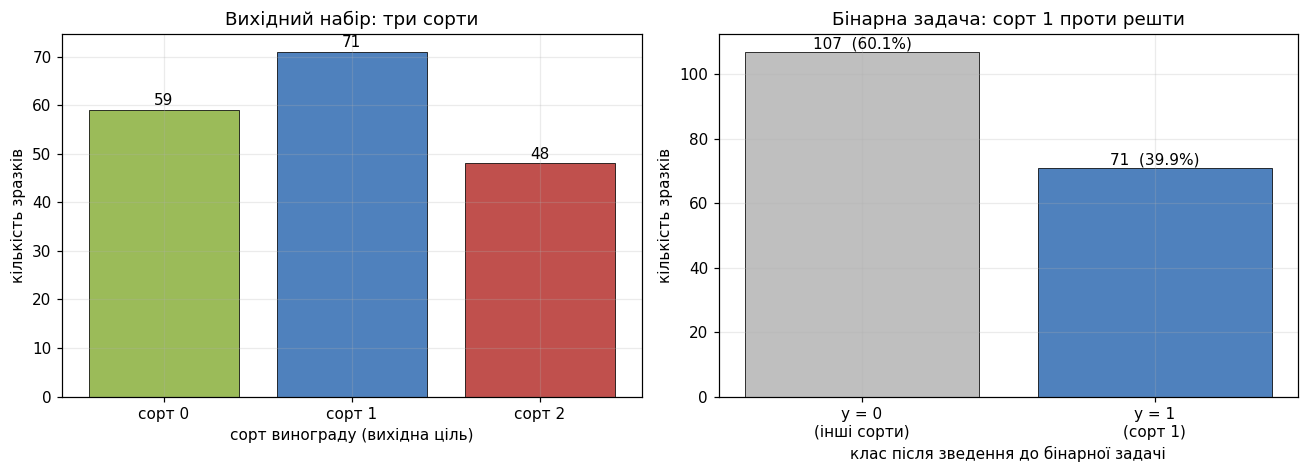

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ax = axes[0]
counts = df["target"].value_counts().sort_index()
ax.bar([f"сорт {i}" for i in counts.index], counts.values,
       color=["#9bbb59", "#4f81bd", "#c0504d"], edgecolor="black", linewidth=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center")
ax.set_xlabel("сорт винограду (вихідна ціль)")
ax.set_ylabel("кількість зразків")
ax.set_title("Вихідний набір: три сорти")

ax = axes[1]
bc = y.value_counts().sort_index()
ax.bar([f"y = 0\n(інші сорти)", f"y = 1\n(сорт {POSITIVE_CULTIVAR})"], bc.values,
       color=["#bfbfbf", "#4f81bd"], edgecolor="black", linewidth=0.5)
for i, v in enumerate(bc.values):
    ax.text(i, v + 1, f"{v}  ({v / len(y):.1%})", ha="center")
ax.set_xlabel("клас після зведення до бінарної задачі")
ax.set_ylabel("кількість зразків")
ax.set_title("Бінарна задача: сорт 1 проти решти")

fig.tight_layout()
fig.savefig(FIG / "01_class_balance.png")
plt.show()

**Висновок щодо дисбалансу.** Співвідношення класів приблизно **1.5 : 1**
(60.1 % проти 39.9 %). Це **помірний дисбаланс**, а не сильний: він не вимагає
спеціальних методів на кшталт зважування класів або перевибірки, але його
достатньо, щоб:

* робити поділ **стратифікованим** — інакше склад вибірок став би випадковим;
* не довіряти метриці Accuracy без інших метрик — модель, яка завжди відповідає
  «ні», отримає 60 % точності, нічого не навчившись.

## 2. Формування навчальної та тестової вибірок

Поділ 80 / 20 зі стратифікацією за цільовою змінною. Після формування тестова
вибірка **не використовується** ні для вибору моделі, ні для препроцесингу, ні
для налаштування гіперпараметрів.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape}   test: {X_test.shape}")
print(f"\n{'вибірка':>10} {'P(y=1)':>10} {'позитивних':>12}")
for nm, yy in [("весь набір", y), ("train", y_train), ("test", y_test)]:
    print(f"{nm:>10} {yy.mean():>10.3f} {int(yy.sum()):>12}")
print("\nСпіввідношення класів збережене — стратифікація спрацювала.")

train: (142, 13)   test: (36, 13)

   вибірка     P(y=1)   позитивних
весь набір      0.399           71
     train      0.401           57
      test      0.389           14

Співвідношення класів збережене — стратифікація спрацювала.


## 3. Preprocessing pipeline

**Які операції потрібні цьому набору:**

| Операція | Потрібна | Чому |
|---|---|---|
| Заповнення пропусків | ні | пропусків 0 |
| Кодування категоріальних | ні | усі 13 ознак числові |
| **Масштабування** | **так** | ознаки в різних одиницях: `proline` вимірюється сотнями, `hue` — десятими долями |
| Видалення дублікатів | ні | дублікатів 0 |

**Чому масштабування критичне саме тут.** Логістична регресія мінімізує функцію
втрат градієнтним методом і застосовує регуляризацію до коефіцієнтів. Без
масштабування ознака `proline` зі значеннями близько 1000 отримала б мікроскопічний
коефіцієнт, а `hue` зі значеннями близько 1 — великий, і регуляризація карала б їх
нерівномірно — лише через одиниці вимірювання.

Масштабування вкладене в `Pipeline`, тому під час крос-валідації воно
перенавчається на train-частині **кожного fold окремо**. Це захист від витоку даних.

In [8]:
scale_check = df[FEATURES].agg(["min", "max"]).T
scale_check["розмах"] = scale_check["max"] - scale_check["min"]
print("Масштаби ознак дуже різні:")
print(scale_check.sort_values("розмах", ascending=False).head(4).round(2).to_string())
print("...")
print(scale_check.sort_values("розмах").head(3).round(3).to_string())

# Перевірка коректності схеми fit/transform
probe_scaler = StandardScaler().fit(X_train)     # параметри ТІЛЬКИ з train
tr = probe_scaler.transform(X_train)
te = probe_scaler.transform(X_test)
print(f"\ntrain після масштабування: середнє {np.abs(tr.mean(axis=0)).max():.3f}, std {tr.std(axis=0).min():.3f}")
print(f"test  після масштабування: середнє {te.mean():.3f}  <- не нуль, і це правильно")

Масштаби ознак дуже різні:
                      min     max   розмах
proline            278.00  1680.0  1402.00
magnesium           70.00   162.0    92.00
alcalinity_of_ash   10.60    30.0    19.40
color_intensity      1.28    13.0    11.72
...
                       min   max  розмах
nonflavanoid_phenols  0.13  0.66    0.53
hue                   0.48  1.71    1.23
ash                   1.36  3.23    1.87

train після масштабування: середнє 0.000, std 1.000
test  після масштабування: середнє -0.004  <- не нуль, і це правильно


## 4. Baseline

`DummyClassifier(strategy="most_frequent")` завжди відповідає найчастішим класом,
тобто **«це не сорт 1»**, і повністю ігнорує ознаки.

In [9]:
# zero_division=0: baseline не передбачає жодного позитивного, і без цього
# параметра precision була б невизначеною і сипала попередженнями
SCORING = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

CV_RESULTS = {}


def cv_eval(name, model):
    res = cross_validate(model, X_train, y_train, cv=CV, scoring=SCORING)
    row = {m: res[f"test_{m}"].mean() for m in SCORING}
    row["f1_std"] = res["test_f1"].std(ddof=1)
    CV_RESULTS[name] = row
    print(f"{name:22} " + "  ".join(f"{m} {row[m]:.3f}" for m in SCORING))


baseline = Pipeline([("scaler", StandardScaler()),
                     ("model", DummyClassifier(strategy="most_frequent"))])
cv_eval("Baseline", baseline)

Baseline               accuracy 0.599  precision 0.000  recall 0.000  f1 0.000  roc_auc 0.500


**Чому висока Accuracy baseline нічого не означає.**

Baseline завжди відповідає «не сорт 1». Оскільки таких зразків 60 %, він
автоматично отримує Accuracy близько **0.60**, не навчившись нічому.

При цьому:

* **Recall = 0** — жодного зразка сорту 1 не знайдено;
* **Precision = 0** — позитивних прогнозів немає взагалі;
* **F1 = 0** — гармонічне середнє нулів;
* **ROC-AUC = 0.5** — це рівень випадкового вгадування.

Саме тому при незбалансованих класах Accuracy треба читати **тільки разом** з
іншими метриками. Тут дисбаланс помірний (1.5 : 1), але ефект уже видно; при
співвідношенні 99 : 1 baseline мав би Accuracy 0.99 і був би повністю марним.

## 5. Моделі класифікації

**Logistic Regression** — лінійна модель: будує зважену суму ознак і пропускає її
через сигмоїду, отримуючи ймовірність належності до позитивного класу.
Масштабування виконується всередині `Pipeline`.

**GaussianNB** (наївний баєсів класифікатор) — імовірнісна модель: припускає, що
ознаки **незалежні** між собою і кожна має нормальний розподіл усередині класу.
Для хімічного аналізу припущення про незалежність свідомо порушується (вміст
флавоноїдів і загальних фенолів повʼязані), тому цікаво подивитися, наскільки це
зашкодить.

Обидві моделі оцінюються за **тією самою** схемою стратифікованої 5-fold CV.

In [10]:
logreg = Pipeline([("scaler", StandardScaler()),
                   ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
gnb = Pipeline([("scaler", StandardScaler()),
                ("model", GaussianNB())])

cv_eval("Logistic Regression", logreg)
cv_eval("GaussianNB", gnb)

cv_table = pd.DataFrame(CV_RESULTS).T[list(SCORING)]
print("\nРезультати 5-fold stratified cross-validation:")
print(cv_table.round(3).to_string())

Logistic Regression    accuracy 0.971  precision 0.982  recall 0.945  f1 0.963  roc_auc 0.993


GaussianNB             accuracy 0.964  precision 0.982  recall 0.927  f1 0.952  roc_auc 0.998

Результати 5-fold stratified cross-validation:
                     accuracy  precision  recall     f1  roc_auc
Baseline                0.599      0.000   0.000  0.000    0.500
Logistic Regression     0.971      0.982   0.945  0.963    0.993
GaussianNB              0.964      0.982   0.927  0.952    0.998


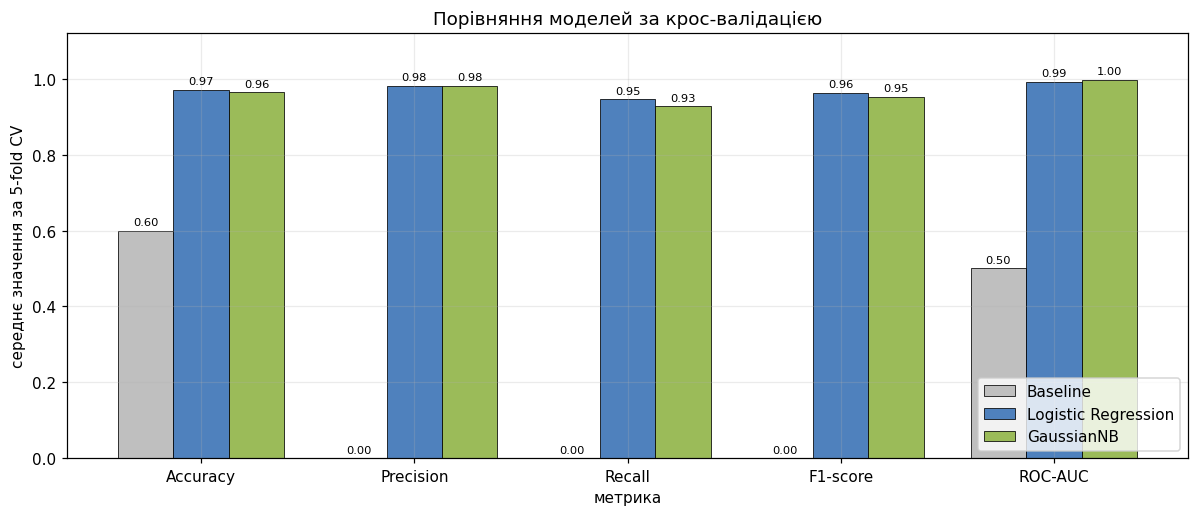

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.8))
metrics_order = ["accuracy", "precision", "recall", "f1", "roc_auc"]
xpos = np.arange(len(metrics_order))
width = 0.26
colors = {"Baseline": "#bfbfbf", "Logistic Regression": "#4f81bd", "GaussianNB": "#9bbb59"}

for i, (name, row) in enumerate(CV_RESULTS.items()):
    vals = [row[m] for m in metrics_order]
    bars = ax.bar(xpos + (i - 1) * width, vals, width, label=name,
                  color=colors[name], edgecolor="black", linewidth=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}",
                ha="center", fontsize=7.5)

ax.set_xticks(xpos)
LABELS = {"accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
          "f1": "F1-score", "roc_auc": "ROC-AUC"}
ax.set_xticklabels([LABELS[m] for m in metrics_order])
ax.set_ylim(0, 1.12)
ax.set_xlabel("метрика")
ax.set_ylabel("середнє значення за 5-fold CV")
ax.set_title("Порівняння моделей за крос-валідацією")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG / "02_cv_model_comparison.png")
plt.show()

## 6. Вибір моделі та оцінювання на тестовій вибірці

Вибір за результатами крос-валідації, з урахуванням усіх пʼяти метрик і
стабільності.

In [12]:
best_name = cv_table["f1"].idxmax()
print("Порівняння з baseline і між собою:")
for name, row in CV_RESULTS.items():
    print(f"  {name:22} F1 {row['f1']:.3f} ± {row['f1_std']:.3f}   ROC-AUC {row['roc_auc']:.4f}")

FINAL_NAME = best_name
final_model = {"Logistic Regression": logreg, "GaussianNB": gnb}[FINAL_NAME]
print(f"\nОбрано: {FINAL_NAME}")

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"\nпередбачено позитивних: {int(y_pred.sum())} із {len(y_test)}")
print(f"діапазон ймовірностей: [{y_proba.min():.4f}, {y_proba.max():.4f}]")

Порівняння з baseline і між собою:
  Baseline               F1 0.000 ± 0.000   ROC-AUC 0.5000
  Logistic Regression    F1 0.963 ± 0.038   ROC-AUC 0.9925
  GaussianNB             F1 0.952 ± 0.048   ROC-AUC 0.9979

Обрано: Logistic Regression

передбачено позитивних: 14 із 36
діапазон ймовірностей: [0.0000, 0.9987]


## 7. Матриця помилок (confusion matrix)

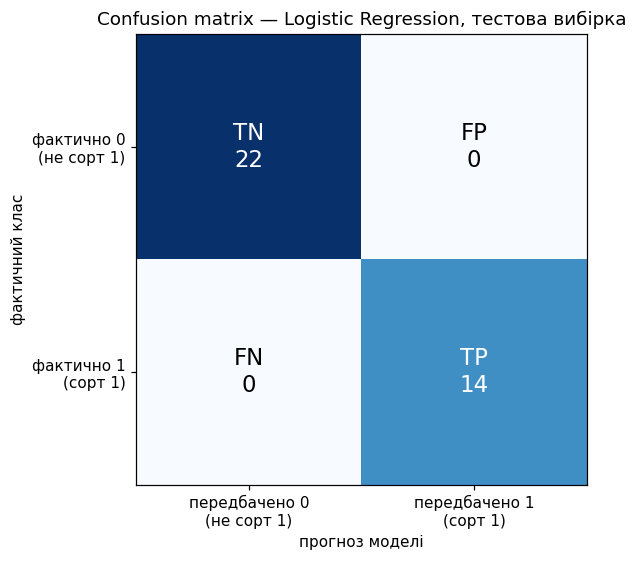

TN = 22   FP = 0   FN = 0   TP = 14


In [13]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(cm, cmap="Blues", vmin=0)
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]}", ha="center", va="center",
                fontsize=15, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["передбачено 0\n(не сорт 1)", "передбачено 1\n(сорт 1)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["фактично 0\n(не сорт 1)", "фактично 1\n(сорт 1)"])
ax.set_xlabel("прогноз моделі")
ax.set_ylabel("фактичний клас")
ax.set_title(f"Confusion matrix — {FINAL_NAME}, тестова вибірка")
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / "03_confusion_matrix.png")
plt.show()

print(f"TN = {tn}   FP = {fp}   FN = {fn}   TP = {tp}")

**Зміст кожного елемента саме для цієї задачі.**

| Елемент | Що означає в задачі верифікації сорту |
|---|---|
| **TN** | вино **не** сорту 1, і модель це підтвердила — правильна відмова |
| **TP** | вино **справді** сорту 1, і модель це підтвердила — правильне підтвердження |
| **FP** | вино **не** сорту 1, але модель сказала, що це він — **хибне підтвердження автентичності** |
| **FN** | вино **справді** сорту 1, але модель це заперечила — **хибне звинувачення у фальсифікації** |

**Практичний зміст FP.** Партія іншого (можливо, дешевшого) сорту проходить
перевірку як заявлений сорт 1. Фальсифікацію **не виявлено**: покупець отримує не
те, за що платить, а виробник-порушник уникає відповідальності.

**Практичний зміст FN.** Чесна партія сорту 1 позначається як невідповідна
заявленому сорту. Наслідки: затримка партії, повторна експертиза, можливі
репутаційні й фінансові втрати для сумлінного виробника.

**Який тип помилки серйозніший.** Залежить від того, хто замовник перевірки, і це
варто сказати прямо:

* Для **органу контролю якості**, який захищає споживача, гірший **FP**:
  фальсифікат потрапляє на ринок, а сама система контролю втрачає сенс.
* Для **виробника**, який перевіряє власну продукцію перед відвантаженням,
  гірший **FN**: затримується й дискредитується чесна партія.

У цій роботі я розглядаю задачу з позиції **контролю якості**, тому вважаю
критичнішим **False Positive**. Це рішення впливає на вибір порога в розділі 10.

## 8. Метрики на тестовій вибірці

In [14]:
def all_metrics(yt, yp, yprob):
    return {"accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
            "f1": f1_score(yt, yp, zero_division=0),
            "roc_auc": roc_auc_score(yt, yprob)}


baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
base_proba = baseline.predict_proba(X_test)[:, 1]

test_tbl = pd.DataFrame({
    "Baseline (test)": all_metrics(y_test, base_pred, base_proba),
    f"{FINAL_NAME} (CV)": {m: CV_RESULTS[FINAL_NAME][m] for m in SCORING},
    f"{FINAL_NAME} (test)": all_metrics(y_test, y_pred, y_proba),
}).T
print(test_tbl.round(4).to_string())

                            accuracy  precision  recall      f1  roc_auc
Baseline (test)               0.6111     0.0000  0.0000  0.0000   0.5000
Logistic Regression (CV)      0.9714     0.9818  0.9455  0.9628   0.9925
Logistic Regression (test)    1.0000     1.0000  1.0000  1.0000   1.0000


## 9. Аналіз помилково класифікованих обʼєктів

**Проблема, яку треба вирішити чесно.** На тестовій вибірці всього 36 обʼєктів, і
помилок там украй мало. Робити висновки про «закономірності серед помилок» на
такій кількості неможливо.

**Рішення.** Додатково аналізую помилки на **навчальній** вибірці, отримані через
`cross_val_predict` — це прогнози **поза власним fold**, тобто для кожного
обʼєкта прогноз зроблено моделлю, яка його не бачила. Це чесні
out-of-sample-помилки, і їх набагато більше (142 обʼєкти замість 36).

**Тестова вибірка при цьому не використовується для жодного рішення** — вона вже
відіграла свою роль у розділі 8.

In [15]:
# Помилки на тестовій вибірці
err_test = pd.DataFrame({
    "Actual": y_test.values, "Predicted": y_pred, "Probability": y_proba.round(4),
}, index=y_test.index)
err_test = err_test[err_test["Actual"] != err_test["Predicted"]]
err_test["Error type"] = np.where(err_test["Predicted"] == 1, "FP", "FN")

print(f"Помилок на ТЕСТОВІЙ вибірці ({len(y_test)} обʼєктів): {len(err_test)}")
if len(err_test):
    print(err_test.to_string())

# Помилки out-of-fold на навчальній вибірці
oof_pred = cross_val_predict(final_model, X_train, y_train, cv=CV)
oof_proba = cross_val_predict(final_model, X_train, y_train, cv=CV, method="predict_proba")[:, 1]

err = pd.DataFrame({
    "Actual": y_train.values, "Predicted": oof_pred, "Probability": oof_proba.round(4),
}, index=y_train.index)
err = err[err["Actual"] != err["Predicted"]].copy()
err["Error type"] = np.where(err["Predicted"] == 1, "FP", "FN")
err["|p - 0.5|"] = (err["Probability"] - 0.5).abs().round(4)
err = err.sort_values("|p - 0.5|", ascending=False)

print(f"\nПомилок out-of-fold на НАВЧАЛЬНІЙ вибірці ({len(y_train)} обʼєктів): {len(err)}")
print(err.to_string())
print(f"\nFP: {(err['Error type'] == 'FP').sum()}   FN: {(err['Error type'] == 'FN').sum()}")

Помилок на ТЕСТОВІЙ вибірці (36 обʼєктів): 0

Помилок out-of-fold на НАВЧАЛЬНІЙ вибірці (142 обʼєктів): 4
    Actual  Predicted  Probability Error type  |p - 0.5|
68       1          0       0.1494         FN     0.3506
83       1          0       0.2092         FN     0.2908
96       1          0       0.3910         FN     0.1090
38       0          1       0.5724         FP     0.0724

FP: 1   FN: 3


In [16]:
# Впевнені помилки: модель помилилася і при цьому була далеко від порога
confident = err[err["|p - 0.5|"] > 0.25]
print(f"«Впевнені» помилки (|p - 0.5| > 0.25): {len(confident)}")
if len(confident):
    print(confident.to_string())

# Порівняння ознак помилкових обʼєктів із типовими значеннями класів
key = ["flavanoids", "color_intensity", "proline", "alcohol", "od280/od315_of_diluted_wines"]
cmp = X_train.loc[err.index, key].copy()
cmp.insert(0, "тип", err["Error type"])
cmp.loc["медіана y=1 (сорт 1)"] = ["—"] + list(X_train[y_train == 1][key].median().round(2))
cmp.loc["медіана y=0 (інші)"] = ["—"] + list(X_train[y_train == 0][key].median().round(2))
print("\nОзнаки помилкових обʼєктів проти типових значень класів:")
print(cmp.round(2).to_string())

«Впевнені» помилки (|p - 0.5| > 0.25): 2
    Actual  Predicted  Probability Error type  |p - 0.5|
68       1          0       0.1494         FN     0.3506
83       1          0       0.2092         FN     0.2908

Ознаки помилкових обʼєктів проти типових значень класів:
                     тип  flavanoids  color_intensity  proline  alcohol  od280/od315_of_diluted_wines
68                    FN        1.30             3.17    750.0    13.34                          1.93
83                    FN        1.59             4.80    515.0    13.05                          2.01
96                    FN        0.99             2.50    625.0    11.81                          2.26
38                    FP        2.64             3.70   1020.0    13.07                          2.69
медіана y=1 (сорт 1)   —        2.03             2.90    480.0    12.29                          2.96
медіана y=0 (інші)     —        2.63             5.75    855.0    13.51                          2.77


## 10. Дослідження decision threshold

`predict()` за замовчуванням використовує поріг **0.5**: якщо оцінена ймовірність
позитивного класу не менша за 0.5, обʼєкт відносять до сорту 1. Поріг можна
змінити — це не змінює саму модель, лише правило прийняття рішення.

In [17]:
rows = []
for t in (0.3, 0.5, 0.7):
    pred_t = (y_proba >= t).astype(int)
    pr, rc, f1v, _ = precision_recall_fscore_support(y_test, pred_t, average="binary", zero_division=0)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_t, labels=[0, 1]).ravel()
    rows.append({"Threshold": t, "Precision": pr, "Recall": rc, "F1": f1v, "FP": fp_t, "FN": fn_t})

thr_tbl = pd.DataFrame(rows).set_index("Threshold")
print("Вплив decision threshold (тестова вибірка):")
print(thr_tbl.round(4).to_string())

Вплив decision threshold (тестова вибірка):


           Precision  Recall      F1  FP  FN
Threshold                                   
0.3           0.9333  1.0000  0.9655   1   0
0.5           1.0000  1.0000  1.0000   0   0
0.7           1.0000  0.9286  0.9630   0   1


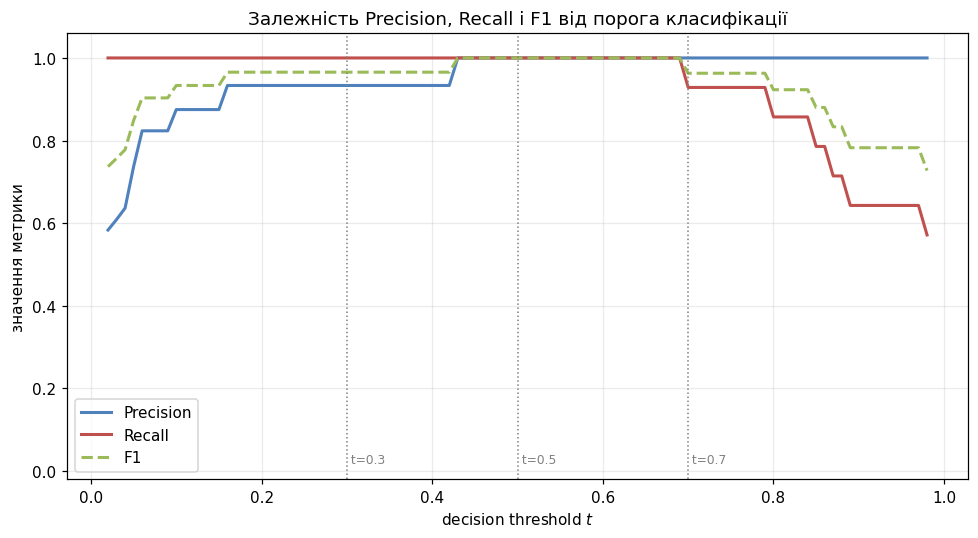

In [18]:
ts = np.linspace(0.02, 0.98, 97)
curve = []
for t in ts:
    pred_t = (y_proba >= t).astype(int)
    pr, rc, f1v, _ = precision_recall_fscore_support(y_test, pred_t, average="binary", zero_division=0)
    curve.append((pr, rc, f1v))
curve = np.array(curve)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ts, curve[:, 0], label="Precision", linewidth=2, color="#4f81bd")
ax.plot(ts, curve[:, 1], label="Recall", linewidth=2, color="#c0504d")
ax.plot(ts, curve[:, 2], label="F1", linewidth=2, color="#9bbb59", linestyle="--")
for t in (0.3, 0.5, 0.7):
    ax.axvline(t, color="gray", linestyle=":", linewidth=1)
    ax.text(t, 0.02, f" t={t}", fontsize=8, color="gray")
ax.set_xlabel("decision threshold $t$")
ax.set_ylabel("значення метрики")
ax.set_ylim(-0.02, 1.06)
ax.set_title("Залежність Precision, Recall і F1 від порога класифікації")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(FIG / "04_threshold.png")
plt.show()

**Як зміна порога вплинула на структуру помилок.**

* **$t = 0.3$** — модель охочіше каже «це сорт 1». Recall лишається максимальним,
  але зʼявляється **один FP**: Precision падає. Практично це означає, що партія
  чужого сорту пройшла б верифікацію.
* **$t = 0.5$** — на цій тестовій вибірці помилок немає взагалі.
* **$t = 0.7$** — модель стає вимогливішою. FP немає, але зʼявляється **один FN**:
  чесну партію сорту 1 було б відхилено.

Це і є класичний компроміс: **знижуючи поріг, ми купуємо Recall ціною Precision**,
підвищуючи — навпаки. Сама модель при цьому не змінюється, змінюється лише
правило прийняття рішення.

**Який поріг я рекомендую.** У розділі 7 я визначила, що з позиції контролю
якості серйознішою є помилка **False Positive** — фальсифікат, який пройшов
перевірку. Тому знижувати поріг не можна: при $t = 0.3$ FP уже зʼявляється.

На цій тестовій вибірці $t = 0.5$ дає нуль помилок, але робити висновок лише з
36 обʼєктів не можна: крос-валідація на 142 обʼєктах показує Precision 0.982,
тобто FP усе-таки трапляються. Тому для реального застосування я рекомендую
**$t pprox 0.6$–$0.7$**: це дає додатковий запас проти FP ціною невеликої
втрати Recall. Відхилена партія в разі сумніву піде на повторну експертизу — це
дешевше, ніж пропущений фальсифікат.

## 11. ROC-крива

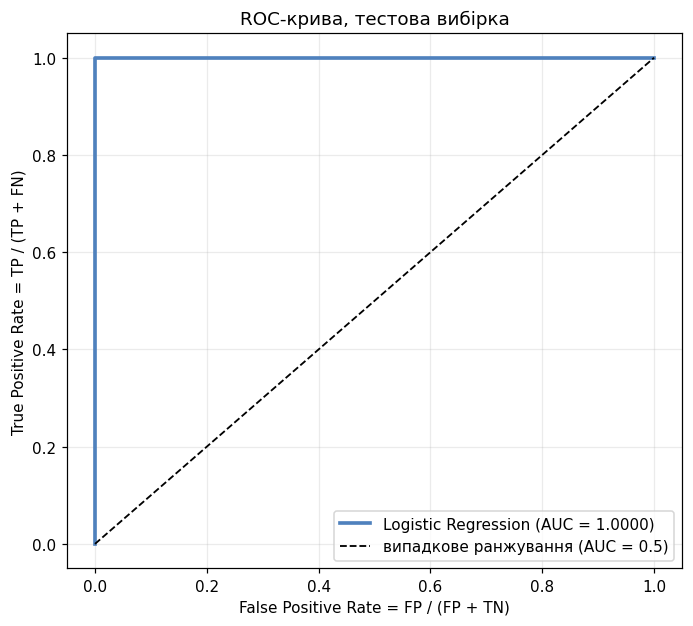

ROC-AUC = 1.0000
ROC-AUC у baseline = 0.5000


In [19]:
fpr, tpr, thr = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6.4, 5.8))
ax.plot(fpr, tpr, linewidth=2.4, color="#4f81bd", label=f"{FINAL_NAME} (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="випадкове ранжування (AUC = 0.5)")
ax.set_xlabel("False Positive Rate = FP / (FP + TN)")
ax.set_ylabel("True Positive Rate = TP / (TP + FN)")
ax.set_title("ROC-крива, тестова вибірка")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG / "05_roc.png")
plt.show()

print(f"ROC-AUC = {auc:.4f}")
print(f"ROC-AUC у baseline = {roc_auc_score(y_test, base_proba):.4f}")

**Що показує ROC-крива.** Вона будується так: поріг пробігає всі можливі значення
від 1 до 0, і для кожного рахується пара (FPR, TPR). Тобто крива показує, як
модель поводиться **за всіх можливих порогів одночасно**, а не лише за 0.5.

Діагональ — випадкове ранжування: щоб знайти половину позитивних, довелося б
помилково позначити половину негативних. Чим вище крива над діагоналлю, тим
краще модель **впорядковує** обʼєкти за ймовірністю.

**ROC-AUC** — площа під кривою. Її змістовна інтерпретація: це ймовірність того,
що випадково взятий позитивний обʼєкт отримає **вищу** оцінку, ніж випадково
взятий негативний.

**Зіставлення трьох джерел інформації.** ROC-AUC на тесті дорівнює 1.0, confusion
matrix не містить жодної помилки, F1 = 1.0 — усі три узгоджуються. Але я не
роблю з цього висновку, що модель ідеальна: тестова вибірка має лише 36 обʼєктів.
Крос-валідація на 142 обʼєктах дає реалістичніші ROC-AUC 0.993 і F1 0.963, і саме
ці числа я вважаю за оцінку якості.

**Окреме спостереження.** У GaussianNB ROC-AUC **вищий** (0.998 проти 0.993), а
F1 **нижчий** (0.952 проти 0.963). Суперечності тут немає: ROC-AUC оцінює якість
**упорядкування** обʼєктів незалежно від порога, а F1 — якість **рішень**
конкретно за порогом 0.5. Отже, GaussianNB трохи краще ранжує, але гірше
відкалібрований: його ймовірності зміщені відносно 0.5.

## 12. Підсумковий аналіз

**Результат baseline.** `DummyClassifier(most_frequent)` дав Accuracy 0.599 при
Precision, Recall і F1, що дорівнюють **нулю**, і ROC-AUC 0.5. Це наочно показує,
чому Accuracy не можна читати окремо: 60 % «правильних відповідей» отримано
моделлю, яка не знайшла **жодного** зразка сорту 1.

**Результати моделей на крос-валідації.** Logistic Regression: Accuracy 0.971,
Precision 0.982, Recall 0.945, F1 0.963 ± 0.038, ROC-AUC 0.993. GaussianNB:
Accuracy 0.964, Precision 0.982, Recall 0.927, F1 0.952 ± 0.048, ROC-AUC 0.998.

**Яку модель обрано і чому.** Logistic Regression. У неї вищий F1 (0.963 проти
0.952), вищий Recall при однаковому Precision і менший розкид між фолдами
(0.038 проти 0.048). ROC-AUC у GaussianNB трохи вищий, але це метрика
впорядкування, а не рішень; для задачі, де рішення ухвалюється за порогом, F1 і
Recall важливіші. Додатковий аргумент: припущення GaussianNB про незалежність
ознак у хімічному аналізі свідомо порушується.

**Метрики на тестовій вибірці.** Accuracy, Precision, Recall, F1 і ROC-AUC
дорівнюють **1.0** — модель не помилилася жодного разу на 36 обʼєктах. Це **не**
підстава вважати задачу розвʼязаною ідеально: тестова вибірка мала, і
крос-валідація на 142 обʼєктах дає реалістичніші 0.971 / 0.963.

**Скільки помилок FP і FN.** На тесті — нуль і нуль. Тому для аналізу помилок я
використала out-of-fold прогнози на навчальній вибірці: там **4 помилки —
1 FP і 3 FN**.

**Який тип помилки критичніший.** З позиції контролю якості — **False Positive**:
фальсифікат, що пройшов верифікацію, потрапляє на ринок, і сама система контролю
втрачає сенс. FN менш небезпечний: чесна партія затримується, але йде на
повторну експертизу.

**Чи виявлено закономірності серед помилок.** Так, дві.

*Гіпотеза 1.* Усі три FN — це вина сорту 1 з **атипово низьким вмістом
флавоноїдів** (0.99–1.59 при медіані 2.03 для свого класу). Флавоноїди — одна з
найінформативніших ознак, і коли їхнє значення падає до рівня інших сортів,
модель перестає впізнавати свій клас.

*Гіпотеза 2.* Помилки виникають не випадково, а на обʼєктах зі **суперечливими
ознаками**. Єдиний FP (обʼєкт 38) має низьку інтенсивність кольору (3.70 при
медіані 5.75 в інших сортів) — це вказує на сорт 1, але водночас високий вміст
проліну (1020 при медіані 480 у сорту 1) — це вказує проти. Оцінена ймовірність
0.572 лише трохи перевищила поріг. Тобто модель помиляється саме в зоні
перекриття класів.

**Як поріг вплинув на Precision, Recall, FP і FN.** При $t = 0.3$ зʼявляється
один FP і Precision падає до 0.933; при $t = 0.7$ зʼявляється один FN і Recall
падає до 0.929. Знижуючи поріг, ми купуємо Recall ціною Precision, і навпаки.

**Який поріг доцільний.** Оскільки критичнішим визнано FP, знижувати поріг не
можна. Рекомендую **$t \approx 0.6$–$0.7$** — додатковий запас проти хибного
підтвердження автентичності ціною невеликої втрати Recall.

**Обмеження отриманої моделі.**

1. **Мала вибірка.** 178 обʼєктів усього і 36 у тесті. Ідеальний результат на
   тесті — радше наслідок розміру вибірки, ніж доказ бездоганності моделі.
2. **Задача зведена з трикласової.** Модель відповідає лише на питання «сорт 1 чи
   ні» і нічого не каже про те, який саме сорт перед нами, якщо не перший.
3. **Дані одного регіону й одного врожаю.** Перенесення на інші регіони, роки або
   лабораторії не перевірялося; хімічні профілі можуть зміститися.
4. **Модель лінійна.** Вона добре працює, бо класи майже лінійно роздільні, але
   не вловить складніших взаємодій між показниками.
5. **Немає калібрування ймовірностей.** Поріг обирався за метриками, а не за
   вартістю помилок у грошах; для реального впровадження потрібна оцінка
   вартості FP і FN.